# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

    The original `Price` column had no missing values. It was an object class and contained thousands separators, so I removed the separators by using `str.replace()` and converted the column to numeric.

2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.

    About 76% of `subject_injury` values are missing. `subject_injury` data seems to be largely missing for Bodily Force, Chemical Irritant, Maximal Restraint Technique, and Taser force types.

3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.

4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

    It reduces variance and artificially concentrates data at the median.

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [89]:
df_nyc = pd.read_csv("data/airbnb_NYC.csv", encoding="cp1252")
df_nyc.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [90]:
price_cleaned = df_nyc["Price"].str.replace(",", "")
df_nyc["Price"] = pd.to_numeric(price_cleaned)
df_nyc.dtypes

Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                           int64
Review Scores Rating          float64
dtype: object

In [74]:
df_police = pd.read_csv("data/mn_police_use_of_force.csv")
df_police.shape

(12925, 13)

In [76]:
missing_prop_subject_injury = df_police["subject_injury"].isnull().sum() / df_police.shape[0]
print(missing_prop_subject_injury)

0.7619342359767892


In [77]:
df_police["subject_injury"] = df_police["subject_injury"].fillna("Missing")
print(df_police["subject_injury"].unique())

['Missing' 'No' 'Yes']


In [78]:
pd.crosstab(df_police["subject_injury"], df_police["force_type"])

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [82]:
df_metabric = pd.read_csv("data/metabric.csv")
df_metabric.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


In [83]:
dict = {"0:LIVING" : 1, "1:DECEASED" : 0}
df_metabric["Overall Survival Status Dummy"] = df_metabric["Overall Survival Status"].map(dict)
print(df_metabric["Overall Survival Status Dummy"].unique())

[1 0]


In [91]:
print(df_nyc["Review Scores Rating"].isnull().sum())

8323


In [92]:
df_nyc["review_scores_rating_na"] = df_nyc["Review Scores Rating"].isnull()
imputation_value = df_nyc["Review Scores Rating"].median()
df_nyc["review_scores_rating_imp"] = df_nyc["Review Scores Rating"].fillna(imputation_value)
print(df_nyc["review_scores_rating_imp"].unique())

[ 94.  96. 100.  90.  98.  93.  91.  97.  95.  99.  85.  86.  80.  88.
  92.  89.  82.  87.  81.  76.  78.  83.  66.  84.  72.  79.  60.  40.
  62.  74.  77.  50.  71.  75.  73.  69.  65.  68.  70.  67.  64.  20.
  57.  58.  43.  63.  55.  47.  53.  49.  30.]


**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?

    `read_excel()`
    
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.

    An observation is a specific instance of a phenomenon; in this case each row in the dataframe is an observation of a shark attack.

4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?

    `Year` ranges from the year 0 to 2026. Since 1940, attacks have increased to 1960, decreased to 1980, then increased to a peak in the late 2010s. Since then they have been decreasing.

5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
   
    73.9% of attacks are unprovoked.

7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

    The attack is more likely to be fatal when the attack is unprovoked. The proportion of provoked attacks that were fatal is 3.4%, while the proportion of unprovoked attacks that were fatal is 32.8%.

In [174]:
df_shark = pd.read_excel("data/GSAF5.xls")
df_shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
df_shark = df_shark.drop(columns=["pdf", "href formula", "href", "Case Number", "Case Number.1", "original order", "Unnamed: 21", "Unnamed: 22"])
df_shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,Right thigh and lower leg stripped of flesh,Y,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,No injury shark knocked man of his board,N,1100hrs,Unknown,Bob Myatt GSAF
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,Puncture wounds to right knee,N,1815hrs,1.7m Seven Gill shark,Bob Myatt GSAF
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie


In [176]:
print(df_shark["Year"].unique())

[2026. 2016. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914. 1913. 1912. 1911. 1910. 1909.
 1908. 1907. 1906. 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1897.
 1896. 1895. 1894. 1893. 1892. 1891. 1890. 1889. 1888. 1887. 1886. 1885.
 1884. 1883. 1882. 1881. 1880. 1879. 1878. 1877. 1876. 1875. 1874. 1873.
 1872. 1871. 1870. 1869. 1868. 1867. 1866. 1865. 18

In [177]:
df_shark["Year"] = pd.to_numeric(df_shark["Year"]).astype("Int64")

In [178]:
df_since_1940 = df_shark[df_shark["Year"] >= 1940]
df_since_1940.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,29th January,2026,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,Right thigh and lower leg stripped of flesh,Y,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...
1,29th January,2026,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,No injury shark knocked man of his board,N,1100hrs,Unknown,Bob Myatt GSAF
2,24th January,2026,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,Puncture wounds to right knee,N,1815hrs,1.7m Seven Gill shark,Bob Myatt GSAF
3,20th January,2026,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF
4,19th January,2026,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie


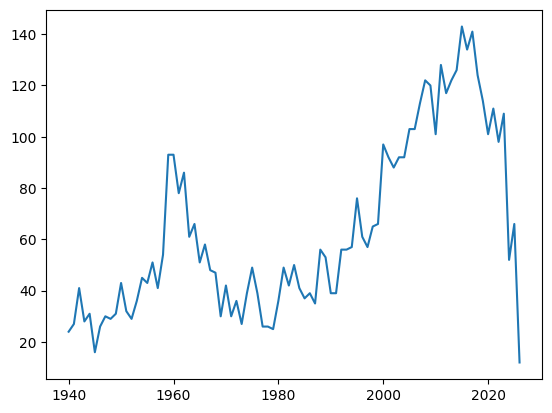

In [179]:
year_counts = df_since_1940["Year"].value_counts().sort_index()
plt.plot(year_counts)
plt.show()

In [180]:
print(df_shark["Age"].unique())

['13' '?' '39' '11' '27' '12' '26' '56' '55' '24' '25' '61' '40' '14'
 '50+' '54' '48' '57' '8' '63' '9' '19' '7' '85' '69' '18' '66' '21' '37'
 '16' '20' '42' '45' '30' '30+' '40+' '29' 35 58 29 24 20 55 17 12 37 36
 23 40 28 69 48 '60+' 57 45 61 27 38 16 68 33 30 15 41 14 43 26
 'Middle age' 18 21 49 25 46 19 65 64 nan '46' '32' '10' '64' '62' '22'
 '15' '52' '44' '47' '59' '50' '34' '38' '30s' '20/30' '35' '65' '20s'
 '77' '60' '49' '!2' '73' '50s' '58' '67' '17' '6' '41' '53' '68' '43'
 '51' '31' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M' 9 31
 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' "20's" 67 74 '9 & 60' 'a minor' 6 3 82 '40?'
 66 72 '23' '36' '71' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5'
 '86' '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'
 '16 to

/var/folders/y8/wry3hv5d7tbfh2t867pyg9_r0000gn/T/ipykernel_18430/1036429922.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric_ages["Age"] = pd.to_numeric(df_numeric_ages["Age"])


<Axes: ylabel='Frequency'>

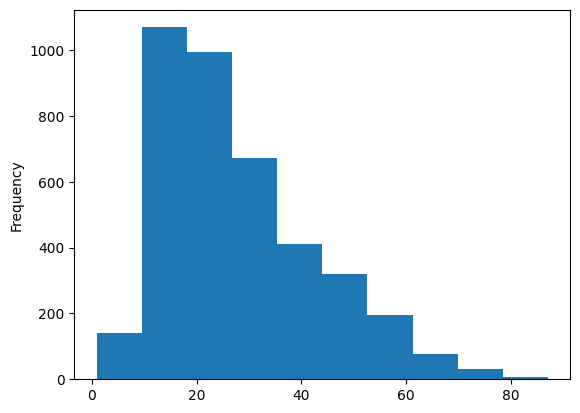

In [181]:
df_shark["age_cleaning"] = df_shark["Age"].str.strip().replace("+", "").replace("!", "").replace("?", "").replace("½", ".5")
df_numeric_ages = df_shark[df_shark["Age"].astype("str").str.isdigit()]
df_numeric_ages["Age"] = pd.to_numeric(df_numeric_ages["Age"])
df_numeric_ages["Age"].plot.hist()

In [182]:
df_shark["Type"].unique()

array(['Unprovoked', 'Provoked', 'Questionable', 'unprovoked',
       ' Provoked', 'Watercraft', 'Sea Disaster', nan, '?', 'Unconfirmed',
       'Unverified', 'Invalid', 'Under investigation', 'Boat'],
      dtype=object)

In [183]:
dict = {"Unprovoked" : "Unprovoked", "Provoked" : "Provoked", "Questionable" : "Unknown", "unprovoked" : "Unprovoked", "Watercraft" : "Unknown", 
        "Sea Disaster" : "Unknown", "?" : "Unknown", "Unconfirmed" : "Unknown", "Unverified" : "Unknown", "Invalid" : "Unknown", 
        "Under Invesitgation" : "Unknown", "Boat" : "Unknown"}
df_shark["Type"] = df_shark["Type"].str.strip().map(dict)
df_shark["Type"] = df_shark["Type"].fillna("Unknown")
print(df_shark["Type"].unique())

['Unprovoked' 'Provoked' 'Unknown']


In [184]:
print(df_shark[df_shark["Type"] == "Unprovoked"].shape[0] / df_shark.shape[0])

0.7387616624257846


In [185]:
df_shark["Fatal Y/N"].unique()

array(['Y', 'N', 'F', 'M', nan, 'n', 'Nq', 'UNKNOWN', 2017, 'Y x 2', ' N',
       'N ', 'y'], dtype=object)

In [186]:
dict = {"Y" : "Y", "N" : "N", "F" : "Y", "M" : "Unknown", "n" : "N", "Nq" : "Unknown", "UNKNOWN" : "Unknown", 2017 : "Unknown", "Y X 2" : "Y", 
        "y" : "Y"}
df_shark["Fatal Y/N"] = df_shark["Fatal Y/N"].str.strip().map(dict)
df_shark["Fatal Y/N"] = df_shark["Fatal Y/N"].fillna("Unknown")
print(df_shark["Fatal Y/N"].unique())

['Y' 'N' 'Unknown']


In [188]:
pd.crosstab(df_shark["Type"], df_shark["Fatal Y/N"])

Fatal Y/N,N,Unknown,Y
Type,,,
Provoked,614,9,21
Unknown,449,553,202
Unprovoked,3879,76,1271


**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  
     The paper is about data tidying, and structuring datasets in a cohesive, standardized way.

  2. Read the introduction. What is the "tidy data standard" intended to accomplish?

     Standardize dataset structure so they can easily be analyzed with a variety of tools without needing to restructure them in a way that makes analysis possible.

  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way."
   
     Different datasets are structured in different ways, but tidy datasets are structured the same way.

     What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."

     Raw datasets are so varied in structure that trying to find a standard definition of variables and observations for use with analytical tools is difficult.

  4. Read Section 2.2. How does Wickham define values, variables, and observations?
   
     Values are qualitative or quantitative. Variables contain all values that measure the same underlying attribute across units. Observations contain all values measured on the same unit across attributes.

  5. How is "Tidy Data" defined in section 2.3?

     Tidy data is structured where each variable is a column, each observation is a row, and each type of observational unit is a table.

  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?

     The 5 most common problems with messy datasets are column headers as values, multiple variables stored in one column, variables stored in rows and columns, multiple types of observational units stored in the same table, and a single observational unit stored in multiple tables.

     In table 4, the rows include variables and observations and some column headers are values for another variable.

     Melting a dataset means to convert columns into rows.

  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

     Table 11 contains variables in rows and columns, specifically tmin and tmax. Table 12 restructures the table so that each column is one variable (turning tmin and tmax into separate columns), and each row is one observation.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? 

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.

   Gift amount is highly right skewed, with a few very high value gift amounts, but the vast majority are below $5,000,000.

3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

   61% are contracts, 39% are real estate, and 0.04% are monetary gifts.

4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions. 
6. Which giftors provide the most money, in total? 

In [189]:
df_gifts = pd.read_csv("data/ForeignGifts_edu.csv")
df_gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


/Users/asong/anaconda3/envs/DS2002/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: ylabel='Frequency'>

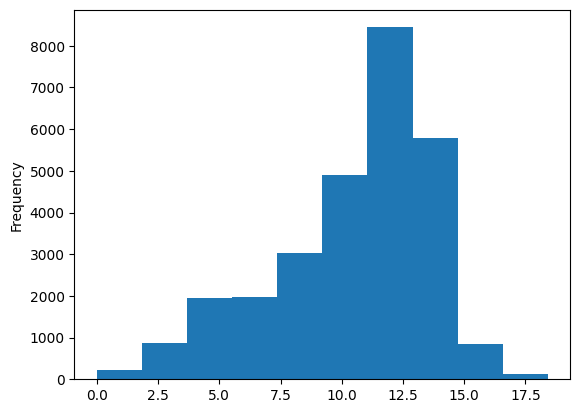

In [215]:
df_gifts["amount_ln"] = np.log(df_gifts["Foreign Gift Amount"])
df_gifts["amount_ln"].plot.hist()

In [218]:
print(df_gifts["Gift Type"].value_counts() / df_gifts.shape[0])

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: count, dtype: float64


In [241]:
df_gifts.groupby("Country of Giftor").count().sort_values(by="ID", ascending=False).head(15)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Giftor Name,amount_ln
Country of Giftor,,,,,,,,,,
ENGLAND,3655,3655,3655,3655,3655,3655,3655,3655,3337,3654
CHINA,2461,2461,2461,2461,2461,2461,2461,2461,2094,2461
CANADA,2344,2344,2344,2344,2344,2344,2344,2344,2101,2344
JAPAN,1896,1896,1896,1896,1896,1896,1896,1896,1626,1891
SWITZERLAND,1676,1676,1676,1676,1676,1676,1676,1676,1530,1676
SAUDI ARABIA,1610,1610,1610,1610,1610,1610,1610,1610,1514,1610
FRANCE,1437,1437,1437,1437,1437,1437,1437,1437,1295,1433
GERMANY,1394,1394,1394,1394,1394,1394,1394,1394,1295,1393
HONG KONG,1080,1080,1080,1080,1080,1080,1080,1080,806,1080


In [244]:
df_gifts.groupby("Country of Giftor").sum().sort_values(by="Foreign Gift Amount", ascending=False).head(15)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Giftor Name,amount_ln
Country of Giftor,,,,,,,,,,
QATAR,14133760,207860000,Arizona State UniversityArizona State Universi...,TempeTempeTempeTempeTempeTempeTempeTempeTempeT...,AZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZ...,29707239,2706240869,ContractContractContractContractContractContra...,RasGas Company LimitedRasGas Company LimitedRa...,8840.929483
ENGLAND,47713393,861644700,University of AlabamaUniversity of AlabamaUniv...,TuscaloosaTuscaloosaBirminghamBirminghamBirmin...,ALALALALALALALALALALALALALALALALALALALALALALAL...,156432837,1464906771,ContractContractContractContractContractContra...,Springer Nature Customer Service CeSpringer Na...,34285.405048
CHINA,33468243,601615400,Jacksonville State UniversityTroy UniversityUn...,JacksonvilleTroyMobileMobileMobileMobileMobile...,ALALALALALALALALALALALALALALALALAZAZAZAZAZAZAZ...,105733871,1237952112,Monetary GiftContractContractContractContractC...,Confucius Institute HeadquartersFujian Univ of...,26517.885326
SAUDI ARABIA,20193035,355691800,University of AlabamaUniversity of AlabamaUniv...,TuscaloosaTuscaloosaTuscaloosaTuscaloosaTuscal...,ALALALALALALALALALALALALALALALALALALALALALALAL...,69276531,1065205930,ContractContractContractContractContractContra...,Saudi Arabia Education MissionSaudi Arabia Edu...,18231.094083
BERMUDA,2126107,31117600,University of Alabama at BirminghamUniversity ...,BirminghamBirminghamBirminghamBirminghamBirmin...,ALALALALALALCACACACACACACACTCTCTDCDCDCDCDCDCIN...,5021524,899593972,ContractContractContractContractContractContra...,"Incysus, LTDIncysus, LTDIncysus, LTDIncysus, L...",1444.825747
CANADA,28437385,499182200,Arizona State UniversityArizona State Universi...,TempeTempeTempeTempeTempeTempeTempeTempeTempeT...,AZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZ...,100285503,898160656,ContractContractMonetary GiftMonetary GiftCont...,University of Western OntarioUniversity of Wes...,19706.307356
HONG KONG,14000547,244471700,California Institute of TechnologyCalifornia I...,PasadenaPasadenaPasadenaPasadenaPasadenaPasade...,CACACACACACACACACACACACACACACACACACACACACACACA...,46351589,887402529,Monetary GiftMonetary GiftMonetary GiftMonetar...,The Shaw FoundationThe Shaw FoundationDr. Ming...,11710.903570
JAPAN,22888812,475343200,University of AlabamaUniversity of AlabamaUniv...,TuscaloosaTuscaloosaTuscaloosaTuscaloosaTuscal...,ALALALALALALALALALAZAZAZAZAZAZAZAZAZAZAZAZAZAZ...,81187641,655954776,ContractContractContractContractContractContra...,Kansai Gaidai University (KGU)Kansai Gaidai Un...,19487.495275
SWITZERLAND,29044550,482048700,Arizona State UniversityArizona State Universi...,TempeTempeTempeTempeTempeTempeTempeTempeTempeT...,AZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZAZ...,71959519,619899445,ContractContractContractContractContractContra...,Hoffman-La RocheHoffman-La RocheHoffman-La Roc...,17909.681324


In [246]:
df_top_institutions = df_gifts.groupby("Institution Name").sum().sort_values(by="Foreign Gift Amount", ascending=False)
df_top_institutions.head(15)

,ID,OPEID,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name,amount_ln
Institution Name,,,,,,,,,,
Carnegie Mellon University,4131857,58031800,PittsburghPittsburghPittsburghPittsburghPittsb...,PAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPAPA...,7644648,1477922504,ContractMonetary GiftContractMonetary GiftCont...,JAPANJAPANSOUTH AFRICAJAPANQATARSOUTH KOREAFRA...,Robert D. Sansom & Edith EligatorLG Electronic...,2506.696184
Cornell University,12905892,177028300,IthacaIthacaIthacaIthacaIthacaIthacaIthacaItha...,NYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNY...,28053214,1289937761,ContractMonetary GiftMonetary GiftContractMone...,MALICANADACANADASOUTH KOREAUNITED ARAB EMIRATE...,L'Institut d'Economie RuraleMs. Heather Yuusoo...,7575.211037
Harvard University,7137015,97621500,CambridgeCambridgeCambridgeCambridgeCambridgeC...,MAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMA...,19288595,954803610,Monetary GiftMonetary GiftMonetary GiftMonetar...,PERUPOLANDQATARSINGAPOREBRAZILCANADACYPRUSENGL...,Contract Party,6224.387209
Massachusetts Institute of Technology,9477579,126759600,CambridgeCambridgeCambridgeCambridgeCambridgeC...,MAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMAMA...,25079475,859071692,Monetary GiftMonetary GiftMonetary GiftMonetar...,CHILEMALAYSIADENMARKHONG KONGPORTUGALBRAZILRUS...,Pontificia Universidad Catolica deUniversiti T...,7692.355665
Yale University,5857775,78430000,New HavenNew HavenNew HavenNew HavenNew HavenN...,CTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCTCT...,23577424,613441311,ContractContractContractContractContractContra...,FRANCEITALYSWITZERLANDGERMANYLITHUANIAHONG KON...,Anonymous #116Anonymous #115Contracting PartyC...,7218.676106
Texas A&M University,9532916,136563200,College StationCollege StationCollege StationC...,TXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTXTX...,16170594,521455050,Monetary GiftContractContractContractContractC...,QATARSAUDI ARABIAQATARQATARQATARSAUDI ARABIAQA...,Maersk OilAramco ServicesQatar FoundationQatar...,4744.840082
Johns Hopkins University,12880872,186722300,BaltimoreBaltimoreBaltimoreBaltimoreBaltimoreB...,MDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMDMD...,38263148,502409595,Monetary GiftMonetary GiftMonetary GiftMonetar...,GHANANORWAYSOUTH AFRICAHAITITANZANIAINDIAJAPAN...,Ministry of FinanceJANSSEN RESEARCH AND DEVELO...,9874.774770
Northwestern University,2994932,43648900,EvanstonEvanstonEvanstonEvanstonEvanstonEvanst...,ILILILILILILILILILILILILILILILILILILILILILILIL...,10759997,402316221,ContractContractContractContractContractContra...,NIGERIACANADAJAPANENGLANDNIGERIANIGERIASOUTH K...,NIH/University of IbadanCorporationsJapan Foun...,3089.897924
Georgetown University,1083975,14016500,WashingtonWashingtonWashingtonWashingtonWashin...,DCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDC...,4151008,379950511,ContractContractMonetary GiftContractContractM...,ENGLANDFRANCEENGLANDCHINAQATARENGLANDSAUDI ARA...,Rio TintoUniversite de VersaillesUK Friends of...,1315.035539


<Axes: ylabel='Frequency'>

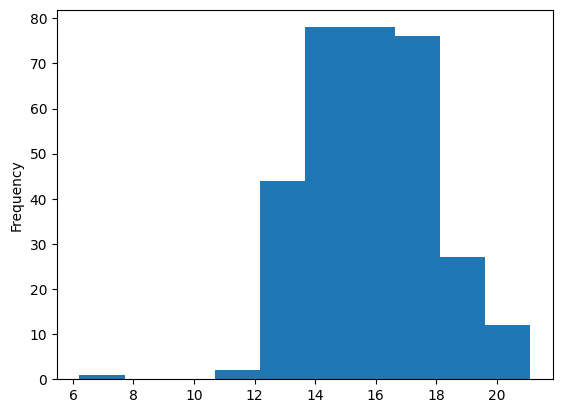

In [248]:
df_top_institutions["foreign_gift_amount_ln"] = np.log(df_top_institutions["Foreign Gift Amount"])
df_top_institutions["foreign_gift_amount_ln"].plot.hist()

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.

   3798 observations and 63 variables.

3. Cross tabulate `control` and `level`. Describe the patterns you see in words.

   Private not-for-profit colleges skew towards 4-years, while public colleges skew towards 2-years, and private for-profit colleges are more similar in number of 2-year and 4-year institutions. 

4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?

   Most 4-year institutions only have between 0% and 25% of first-time, full-time, degree-seeking undergraduates complete a degree or certificate program within 100 percent of expected time.

   Private not-for-profit schools seem to have the most favorable graduation rates.

5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

   `grad_100_value` seems to be roughly positively correlated with `aid_value`.

   `aid_value` seems to not be strongly correlated with `grad_100_value` for private for-profit and public institutions. Aid seemes to vary positively for private not-for-profit institutions.


In [252]:
df_college = pd.read_csv("data/college_completion.csv")
df_college.shape

(3798, 63)

In [253]:
df_college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [254]:
pd.crosstab(df_college["control"], df_college["level"])

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


<Axes: ylabel='Density'>

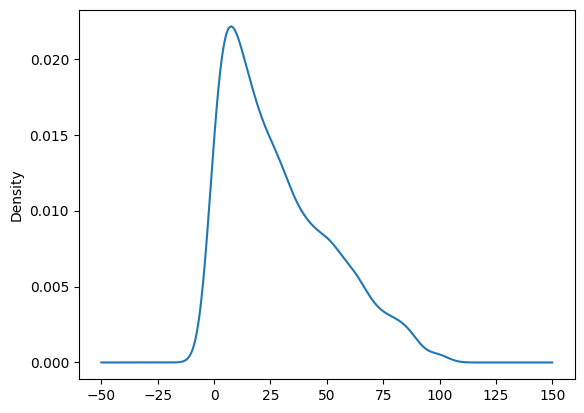

In [ ]:
df_college["grad_100_value"].plot.kde()

<Axes: xlabel='grad_100_value', ylabel='Density'>

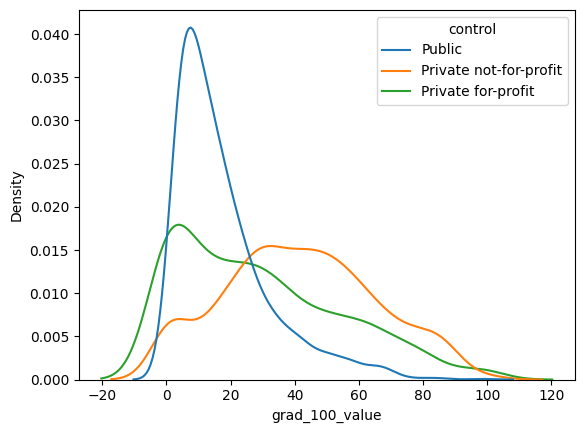

In [274]:
sns.kdeplot(df_college, x="grad_100_value", hue="control", common_norm=False)

<Axes: xlabel='grad_100_value', ylabel='aid_value'>

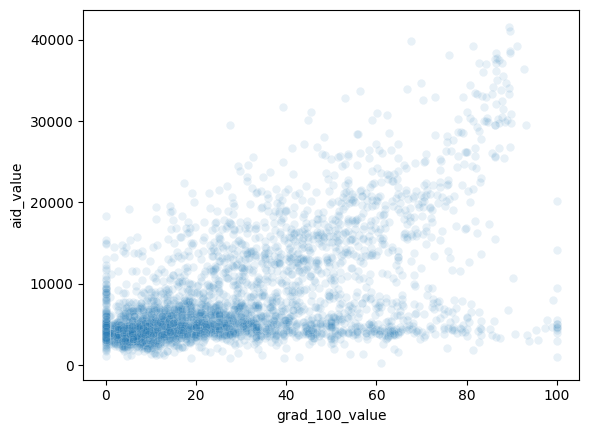

In [277]:
sns.scatterplot(x=df_college["grad_100_value"], y=df_college["aid_value"], alpha=0.1)

In [278]:
df_college.loc[:, ["grad_100_value", "aid_value"]].cov(numeric_only=True)

,grad_100_value,aid_value
grad_100_value,543.483382,8.861048e+04
aid_value,88610.483169,4.121201e+07


In [279]:
df_college.loc[:, ["grad_100_value", "aid_value"]].corr(numeric_only=True)

,grad_100_value,aid_value
grad_100_value,1.000000,0.575879
aid_value,0.575879,1.000000


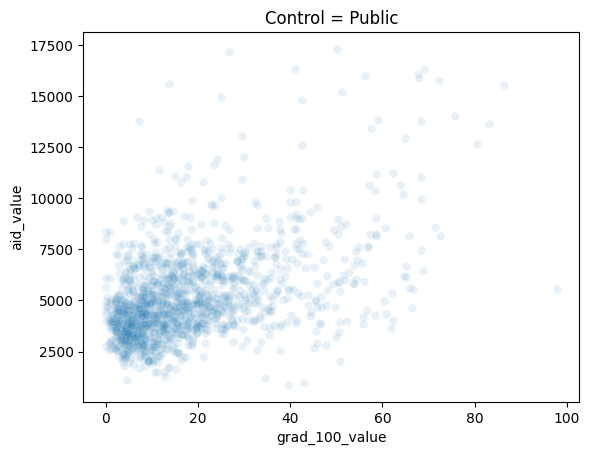

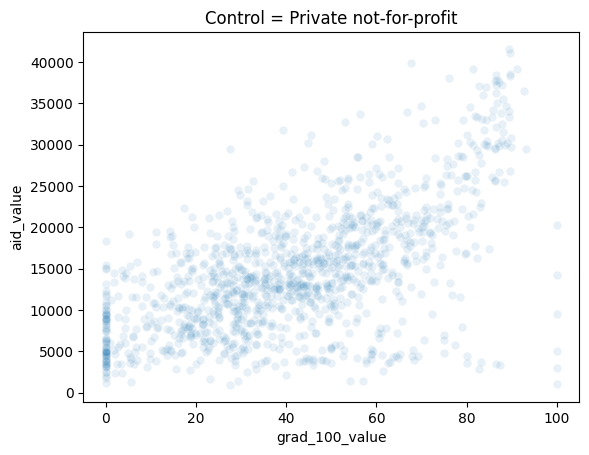

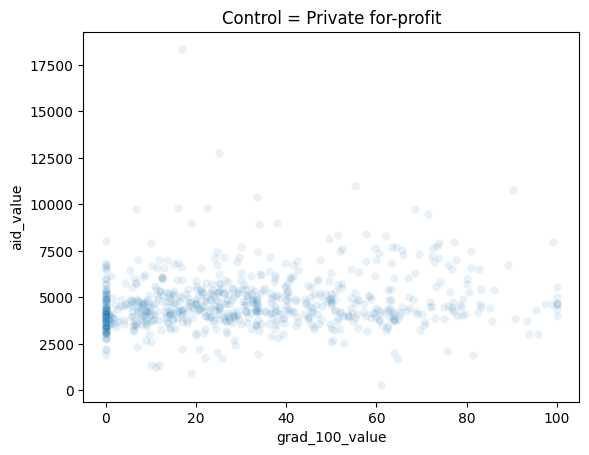

In [281]:
for group in df_college["control"].unique():
    subset = df_college[df_college["control"] == group]
    sns.scatterplot(x=subset["grad_100_value"], y=subset["aid_value"], alpha=0.1)
    plt.title(f"Control = {group}")
    plt.show()

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$. 

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?

   Townhouses are the most expensive on average. Single-family homes have the highest variance in price.

3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?

   There are 

5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

<Axes: ylabel='Density'>

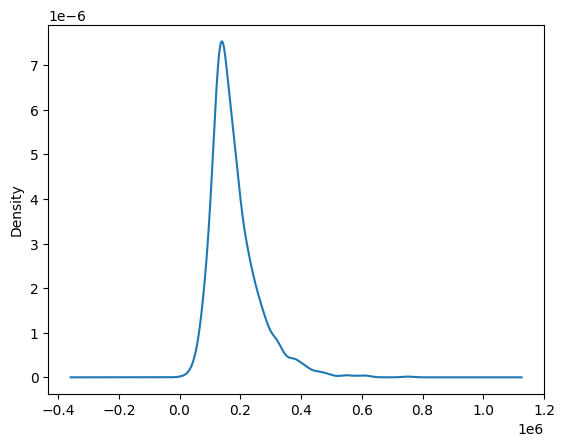

In [283]:
df_ames = pd.read_csv("data/ames_prices.csv")
df_ames["price"].plot.kde()

In [284]:
df_ames["price"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Density'>

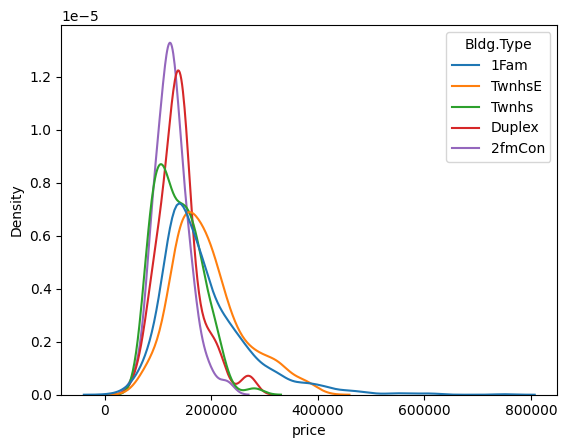

In [285]:
sns.kdeplot(df_ames, x="price", hue="Bldg.Type", common_norm=False)

In [286]:
df_ames.groupby("Bldg.Type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
Bldg.Type,,,,,,,,
1Fam,2425.0,184812.041237,82821.802329,12789.0,130000.0,165000.0,220000.0,755000.0
2fmCon,62.0,125581.709677,31089.239840,55000.0,106562.5,122250.0,140000.0,228950.0
Duplex,109.0,139808.935780,39498.973534,61500.0,118858.0,136905.0,153337.0,269500.0
Twnhs,101.0,135934.059406,41938.931130,73000.0,100500.0,130000.0,170000.0,280750.0
TwnhsE,233.0,192311.914163,66191.738021,71000.0,145000.0,180000.0,222000.0,392500.0


<Axes: xlabel='price', ylabel='Proportion'>

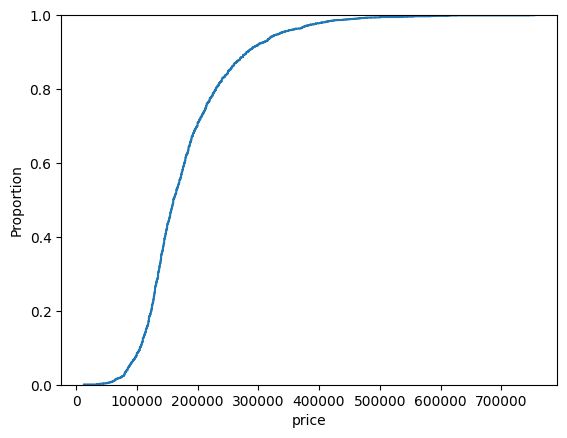

In [288]:
sns.ecdfplot(df_ames["price"])

In [289]:
five_num_sum = df_ames["price"].quantile([0,0.25, 0.5, 0.75, 1])
print(five_num_sum)

0.00     12789.0
0.25    129500.0
0.50    160000.0
0.75    213500.0
1.00    755000.0
Name: price, dtype: float64


<Axes: >

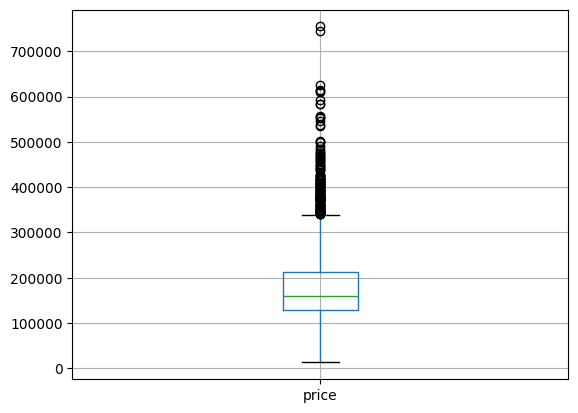

In [291]:
df_ames.boxplot("price")